In [3]:
import os
import shutil
from pathlib import Path
import pandas as pd
import shutil
import random

import sys
from PIL import Image
import torch
import torchvision
import timm
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import cohen_kappa_score
from collections import Counter
import torch.nn.functional as F
import torch.optim as optim

import torch.nn as nn


print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /user/HS402/sm04533/Downloads/AMLv2/myenv/bin/python


In [4]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
GPU: NVIDIA RTX A4000


In [9]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32 # CHANGED FROM 32
NUM_CLASSES = 5
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#DATA_DIR = Path("/kaggle/working/SplitDATA") / "data"
DATA_DIR = Path("SplitDATA") / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_NAME = "deit_small_distilled_patch16_224"
MODEL_NAME_BASELINE = "deit_small_patch16_224"

TEACHER_NAME = "regnety_160"

NUM_EPOCHS = 12
TEACHER_EPOCHS = 12
LEARNING_RATE = 5e-5 #1e-4
ALPHA = 0.2
#ALPHA = 0.3
TAU = 2.0
# LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.05
# ALPHA = 0.5
# TAU = 1.0
PATIENCE = 8 #5


In [ ]:
class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(NUM_CLASSES):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


# train_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(15),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop( # add on exp 8
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.15
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = DRDataset(TRAIN_DIR, transform=train_transform)
val_dataset = DRDataset(VAL_DIR, transform=val_test_transform)
test_dataset = DRDataset(TEST_DIR, transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")


class_counts = Counter(train_dataset.labels)
print("Class counts:", class_counts)


class_weights = None

print("Class weights disabled to prevent severe-class overprediction.")

from torch.utils.data import WeightedRandomSampler
from collections import Counter



sample_weights = [ 
    1.0 / class_counts[label]
    for label in train_dataset.labels
]

sampler = WeightedRandomSampler( 
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False, 
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nData loaders ready!")

Train dataset: 21074 images
Val dataset:   7026 images
Test dataset:  7026 images
Class counts: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Class weights disabled to prevent severe-class overprediction.

Data loaders ready!


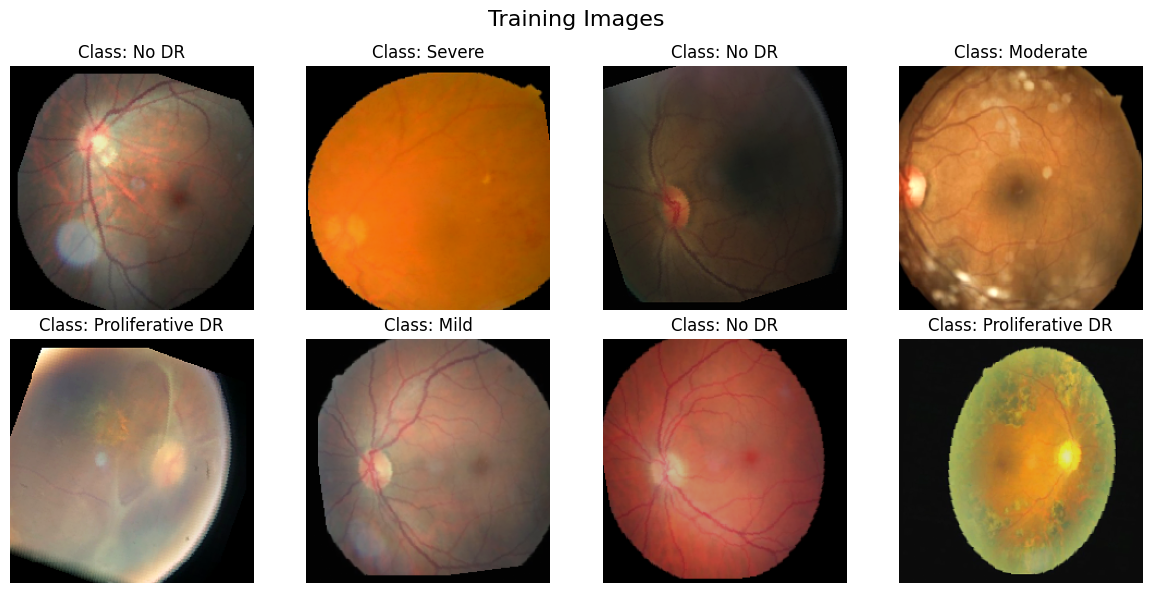

In [ ]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

In [ ]:
# creating FULL DeiT student model
student_model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)

print(f"Student model: {MODEL_NAME}")
print(f"Total params: {total_params/1e6:.2f}M")
print(f"Trainable params: {trainable_params/1e6:.2f}M")

In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, cohen_kappa_score

os.makedirs("SplitDATA/checkpoints", exist_ok=True)
os.makedirs("SplitDATA/logs", exist_ok=True)

teacher_ckpt = "SplitDATA/checkpoints/teacher_regnety160_best.pth"
teacher_log_path = "SplitDATA/logs/teacher_training_log.txt"

teacher_model = timm.create_model(
    TEACHER_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

# criterion_teacher = nn.CrossEntropyLoss(
    # #weight=class_weights, 
    # label_smoothing=0.05 
# )

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=self.label_smoothing
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()


def train_teacher_if_needed(model, train_loader, val_loader, ckpt_path, epochs=TEACHER_EPOCHS):

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print("Loaded existing teacher checkpoint")
        return model

    # Teacher loss
    criterion_teacher = FocalLoss(
        gamma=2.0,
        label_smoothing=0.05
    )

    optimizer_teacher = optim.AdamW(
        model.parameters(),
        lr=5e-5,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_teacher = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_teacher,
        T_max=epochs,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=torch.cuda.is_available()
    )

    best_val_qwk = -1.0
    best_val_f1 = -1.0

    with open(teacher_log_path, "w") as f:
        f.write("====================================================\n")
        f.write("Teacher Training Log - RegNetY-160\n")
        f.write("====================================================\n\n")
        f.write(f"Teacher Model: {TEACHER_NAME}\n")
        f.write(f"Epochs: {epochs}\n")
        f.write("Loss: FocalLoss(gamma=2.0, label_smoothing=0.05)\n")
        f.write("Optimizer: AdamW\n")
        f.write("Learning Rate: 5e-5\n")
        f.write(f"Weight Decay: {WEIGHT_DECAY}\n\n")

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        train_preds, train_labels = [], []

        for images, labels in tqdm(
            train_loader,
            desc=f"Teacher Train {epoch+1}/{epochs}",
            leave=False
        ):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_teacher.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer_teacher)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer_teacher)
            scaler.update()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            train_preds.extend(preds.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader)

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(
            train_labels,
            train_preds,
            average="macro",
            zero_division=0
        )

        model.eval()

        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():

            for images, labels in tqdm(
                val_loader,
                desc=f"Teacher Val {epoch+1}/{epochs}",
                leave=False
            ):

                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)

        val_acc = accuracy_score(val_labels, val_preds)

        val_bal_acc = balanced_accuracy_score(
            val_labels,
            val_preds
        )

        val_f1 = f1_score(
            val_labels,
            val_preds,
            average="macro",
            zero_division=0
        )

        val_qwk = cohen_kappa_score(
            val_labels,
            val_preds,
            weights="quadratic"
        )

        scheduler_teacher.step()

        epoch_log = (
            f"\n====================================================\n"
            f"Teacher Epoch {epoch+1}/{epochs}\n"
            f"====================================================\n"
            f"Train Loss          : {train_loss:.4f}\n"
            f"Train Accuracy      : {train_acc*100:.2f}%\n"
            f"Train Macro-F1      : {train_f1:.4f}\n\n"
            f"Val Loss            : {val_loss:.4f}\n"
            f"Val Accuracy        : {val_acc*100:.2f}%\n"
            f"Val Balanced Acc    : {val_bal_acc:.4f}\n"
            f"Val Macro-F1        : {val_f1:.4f}\n"
            f"Val QWK             : {val_qwk:.4f}\n"
        )

        print(epoch_log)

        with open(teacher_log_path, "a") as f:
            f.write(epoch_log)

        if val_qwk > best_val_qwk:

            best_val_qwk = val_qwk
            best_val_f1 = val_f1

            torch.save(model.state_dict(), ckpt_path)

            msg = (
                f"\nBest teacher saved\n"
                f"Best Val QWK      : {best_val_qwk:.4f}\n"
                f"Val Macro-F1      : {best_val_f1:.4f}\n"
            )

            print(msg)

            with open(teacher_log_path, "a") as f:
                f.write(msg)

    model.load_state_dict(
        torch.load(
            ckpt_path,
            map_location=DEVICE
        )
    )

    final_msg = (
        f"\nTeacher ready\n"
        f"Best Val QWK      : {best_val_qwk:.4f}\n"
        f"Best Val Macro-F1 : {best_val_f1:.4f}\n"
    )

    print(final_msg)

    with open(teacher_log_path, "a") as f:
        f.write(final_msg)

    return model


teacher_model = train_teacher_if_needed(
    teacher_model,
    train_loader,
    val_loader,
    teacher_ckpt,
    epochs=TEACHER_EPOCHS
)

teacher_model.eval()

for p in teacher_model.parameters():
    p.requires_grad = False

print("Teacher loaded and frozen for distillation.")


Teacher Epoch 1/12
Train Loss          : 0.6822
Train Accuracy      : 47.59%
Train Macro-F1      : 0.4736

Val Loss            : 0.5629
Val Accuracy        : 66.45%
Val Balanced Acc    : 0.4996
Val Macro-F1        : 0.4127
Val QWK             : 0.4569


Best teacher saved
Best Val QWK      : 0.4569
Val Macro-F1      : 0.4127




Teacher Epoch 2/12
Train Loss          : 0.4702
Train Accuracy      : 61.53%
Train Macro-F1      : 0.6150

Val Loss            : 0.4861
Val Accuracy        : 59.85%
Val Balanced Acc    : 0.4869
Val Macro-F1        : 0.4547
Val QWK             : 0.5556


Best teacher saved
Best Val QWK      : 0.5556
Val Macro-F1      : 0.4547




Teacher Epoch 3/12
Train Loss          : 0.3593
Train Accuracy      : 70.25%
Train Macro-F1      : 0.7009

Val Loss            : 0.4671
Val Accuracy        : 64.84%
Val Balanced Acc    : 0.4754
Val Macro-F1        : 0.4383
Val QWK             : 0.5854


Best teacher saved
Best Val QWK      : 0.5854
Val Macro-F1      : 0.4383




Teacher Epoch 4/12
Train Loss          : 0.2886
Train Accuracy      : 75.65%
Train Macro-F1      : 0.7553

Val Loss            : 0.5611
Val Accuracy        : 51.15%
Val Balanced Acc    : 0.4783
Val Macro-F1        : 0.4346
Val QWK             : 0.4980




Teacher Epoch 5/12
Train Loss          : 0.2371
Train Accuracy      : 80.68%
Train Macro-F1      : 0.8069

Val Loss            : 0.5042
Val Accuracy        : 60.30%
Val Balanced Acc    : 0.4927
Val Macro-F1        : 0.4468
Val QWK             : 0.5427



...


Teacher Epoch 10/12
Train Loss          : 0.0677
Train Accuracy      : 95.45%
Train Macro-F1      : 0.9545

Val Loss            : 0.5379
Val Accuracy        : 72.39%
Val Balanced Acc    : 0.4714
Val Macro-F1        : 0.4861
Val QWK             : 0.6129


Best teacher saved
Best Val QWK      : 0.6129
Val Macro-F1      : 0.4861




Teacher Epoch 11/12
Train Loss          : 0.0558
Train Accuracy      : 96.46%
Train Macro-F1      : 0.9643

Val Loss            : 0.5594
Val Accuracy        : 74.00%
Val Balanced Acc    : 0.4661
Val Macro-F1        : 0.4931
Val QWK             : 0.6323


Best teacher saved
Best Val QWK      : 0.6323
Val Macro-F1      : 0.4931




Teacher Epoch 12/12
Train Loss          : 0.0493
Train Accuracy      : 97.00%
Train Macro-F1      : 0.9699

Val Loss            : 0.5615
Val Accuracy        : 75.65%
Val Balanced Acc    : 0.4746
Val Macro-F1        : 0.5010
Val QWK             : 0.6450


Best teacher saved
Best Val QWK      : 0.6450
Val Macro-F1      : 0.5010



/tmp/ipykernel_617293/349478398.py:223: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Teacher ready
Best Val QWK      : 0.6450
Best Val Macro-F1 : 0.5010

Teacher loaded and frozen for distillation.


In [ ]:

import torch.optim as optim
# Distillation training setup
# criterion_cls = nn.CrossEntropyLoss(
#     #weight=class_weights,
#     label_smoothing=0.05
# )

class FocalLoss(nn.Module): #exp 7
    def __init__(self, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=self.label_smoothing
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

criterion_cls = FocalLoss(
    gamma=2.0,
    label_smoothing=0.05
)

criterion_dist = nn.KLDivLoss(
    reduction="batchmean"
)

optimizer = optim.AdamW(
    student_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print("Distillation training setup complete")
print(f"Classification Loss: FocalLoss(gamma=2.0, label_smoothing=0.05)")
print(f"Distillation Loss: KLDivLoss")
print(f"ALPHA = {ALPHA}, TAU = {TAU}")

Distillation training setup complete
Classification Loss: FocalLoss(gamma=2.0, label_smoothing=0.05)
Distillation Loss: KLDivLoss
ALPHA = 0.2, TAU = 2.0


In [ ]:

# DeiT WITHOUT DISTILLATION token/ Uses normal DeiT, no teacher

baseline_model = timm.create_model(
    MODEL_NAME_BASELINE,
    pretrained=True,
    num_classes=5
).to(DEVICE)

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

baseline_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer,
    T_max=NUM_EPOCHS
)

baseline_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

best_baseline_qwk = -1.0
baseline_patience_counter = 0

baseline_log_path = "SplitDATA/logs/deit_without_distillation_log.txt"

with open(baseline_log_path, "w") as f:
    f.write("=====================================================\n")
    f.write("DeiT WITHOUT Distillation Training Log\n")
    f.write("=====================================================\n\n")
    f.write(f"Model: {MODEL_NAME_BASELINE}\n")
    f.write("Teacher Used: No\n")
    f.write("Loss: CrossEntropy only\n\n")

for epoch in range(1, NUM_EPOCHS + 1):

    baseline_model.train()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"No-Distill Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        baseline_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

        baseline_scaler.scale(loss).backward()

        baseline_scaler.unscale_(baseline_optimizer)
        torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), max_norm=1.0)

        baseline_scaler.step(baseline_optimizer)
        baseline_scaler.update()
        

        train_loss += loss.item()

        preds = logits.argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    baseline_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"No-Distill Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

            val_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

    baseline_scheduler.step()

    epoch_log = (
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"Train Loss          : {train_loss:.4f}\n"
        f"Train Accuracy      : {train_acc*100:.2f}%\n"
        f"Train Macro-F1      : {train_f1:.4f}\n"
        f"Validation Loss     : {val_loss:.4f}\n"
        f"Validation Accuracy : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc  : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1 : {val_f1:.4f}\n"
        f"Validation QWK      : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(baseline_log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_baseline_qwk:

        best_baseline_qwk = val_qwk
        baseline_patience_counter = 0

        torch.save(
            baseline_model.state_dict(),
            "SplitDATA/checkpoints/best_deit_without_distillation.pth"
        )

        msg = f"\nBest no-distillation DeiT saved | Val QWK: {val_qwk:.4f}\n"
        print(msg)

        with open(baseline_log_path, "a") as f:
            f.write(msg)

    else:

        baseline_patience_counter += 1

        if baseline_patience_counter >= PATIENCE:
            stop_msg = f"\nEarly stopping at epoch {epoch}\n"
            print(stop_msg)

            with open(baseline_log_path, "a") as f:
                f.write(stop_msg)

            break

print(f"DeiT without distillation complete | Best Val QWK: {best_baseline_qwk:.4f}")


Epoch 01/12
Train Loss          : 0.6461
Train Accuracy      : 49.28%
Train Macro-F1      : 0.4903
Validation Loss     : 0.5586
Validation Accuracy : 52.58%
Validation Bal Acc  : 0.4785
Validation Macro-F1 : 0.4171
Validation QWK      : 0.4497


Best no-distillation DeiT saved | Val QWK: 0.4497




Epoch 02/12
Train Loss          : 0.4641
Train Accuracy      : 61.86%
Train Macro-F1      : 0.6163
Validation Loss     : 0.6159
Validation Accuracy : 44.68%
Validation Bal Acc  : 0.4613
Validation Macro-F1 : 0.3707
Validation QWK      : 0.4184




Epoch 03/12
Train Loss          : 0.3677
Train Accuracy      : 68.42%
Train Macro-F1      : 0.6830
Validation Loss     : 0.5119
Validation Accuracy : 60.33%
Validation Bal Acc  : 0.4871
Validation Macro-F1 : 0.4462
Validation QWK      : 0.5215


Best no-distillation DeiT saved | Val QWK: 0.5215




Epoch 04/12
Train Loss          : 0.3084
Train Accuracy      : 73.99%
Train Macro-F1      : 0.7398
Validation Loss     : 0.5327
Validation Accuracy : 60.79%
Validation Bal Acc  : 0.4720
Validation Macro-F1 : 0.4411
Validation QWK      : 0.4640




Epoch 05/12
Train Loss          : 0.2489
Train Accuracy      : 78.98%
Train Macro-F1      : 0.7880
Validation Loss     : 0.5826
Validation Accuracy : 48.43%
Validation Bal Acc  : 0.4568
Validation Macro-F1 : 0.4209
Validation QWK      : 0.4645



...


Epoch 08/12
Train Loss          : 0.1355
Train Accuracy      : 89.07%
Train Macro-F1      : 0.8905
Validation Loss     : 0.5646
Validation Accuracy : 60.20%
Validation Bal Acc  : 0.4287
Validation Macro-F1 : 0.4263
Validation QWK      : 0.4806




Epoch 09/12
Train Loss          : 0.1092
Train Accuracy      : 91.65%
Train Macro-F1      : 0.9169
Validation Loss     : 0.5564
Validation Accuracy : 65.04%
Validation Bal Acc  : 0.4357
Validation Macro-F1 : 0.4347
Validation QWK      : 0.5041




Epoch 10/12
Train Loss          : 0.0904
Train Accuracy      : 93.07%
Train Macro-F1      : 0.9297
Validation Loss     : 0.5447
Validation Accuracy : 70.55%
Validation Bal Acc  : 0.4302
Validation Macro-F1 : 0.4472
Validation QWK      : 0.5526


Best no-distillation DeiT saved | Val QWK: 0.5526




Epoch 11/12
Train Loss          : 0.0768
Train Accuracy      : 94.41%
Train Macro-F1      : 0.9433
Validation Loss     : 0.5579
Validation Accuracy : 70.48%
Validation Bal Acc  : 0.4289
Validation Macro-F1 : 0.4502
Validation QWK      : 0.5562


Best no-distillation DeiT saved | Val QWK: 0.5562




Epoch 12/12
Train Loss          : 0.0726
Train Accuracy      : 94.91%
Train Macro-F1      : 0.9482
Validation Loss     : 0.5578
Validation Accuracy : 70.01%
Validation Bal Acc  : 0.4402
Validation Macro-F1 : 0.4546
Validation QWK      : 0.5499

DeiT without distillation complete | Best Val QWK: 0.5562


In [ ]:
# Full DeiT distillation training

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score
)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs

log_path = "SplitDATA/logs/training_log.txt"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

with open(log_path, "w") as f:
    f.write("=========================================================\n")
    f.write("Diabetic Retinopathy DeiT Distillation Training Log\n")
    f.write("=========================================================\n\n")

    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Image Size: {IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Epochs: {NUM_EPOCHS}\n")
    f.write(f"Patience: {PATIENCE}\n")
    f.write(f"Temperature TAU: {TAU}\n")
    f.write(f"Distillation Alpha: {ALPHA}\n\n")

    f.write("=========================================================\n")
    f.write("EPOCH RESULTS\n")
    f.write("=========================================================\n")

best_val_qwk = -1.0
best_val_f1 = -1.0
patience_counter = 0

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_f1": [],
    "val_qwk": []
}

for epoch in range(1, NUM_EPOCHS + 1):

    student_model.train()
    teacher_model.eval()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            teacher_logits = teacher_model(images)

        with torch.amp.autocast("cuda", enabled=use_amp):

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
   

        train_loss += loss.item()

        preds = ((cls_logits + dist_logits) / 2.0).argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    student_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            teacher_logits = teacher_model(images)

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

            val_loss += loss.item()

            final_logits = (cls_logits + dist_logits) / 2.0
            preds = final_logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_qwk = cohen_kappa_score(
        val_labels,
        val_preds,
        weights="quadratic"
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_f1"].append(val_f1)
    history["val_qwk"].append(val_qwk)

    epoch_log = (
        f"\n=========================================================\n"
        f"Epoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"=========================================================\n"
        f"Train Loss           : {train_loss:.4f}\n"
        f"Train Accuracy       : {train_acc*100:.2f}%\n"
        f"Train Macro-F1       : {train_f1:.4f}\n\n"
        f"Validation Loss      : {val_loss:.4f}\n"
        f"Validation Accuracy  : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc   : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1  : {val_f1:.4f}\n"
        f"Validation QWK       : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_val_qwk:

        best_val_qwk = val_qwk
        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            student_model.state_dict(),
            "SplitDATA/checkpoints/best_distilled_deit_model.pth"
        )

        best_msg = (
            f"\nBEST MODEL SAVED\n"
            f"Validation QWK      : {val_qwk:.4f}\n"
            f"Validation Macro-F1 : {val_f1:.4f}\n"
        )

        print(best_msg)

        with open(log_path, "a") as f:
            f.write(best_msg)

    else:

        patience_counter += 1

        patience_msg = (
            f"\nNo QWK improvement. "
            f"Patience Counter: {patience_counter}/{PATIENCE}\n"
        )

        print(patience_msg)

        with open(log_path, "a") as f:
            f.write(patience_msg)

        if patience_counter >= PATIENCE:

            stop_msg = f"\nEarly stopping at epoch {epoch}\n"

            print(stop_msg)

            with open(log_path, "a") as f:
                f.write(stop_msg)

            break

final_summary = (
    f"\n=========================================================\n"
    f"TRAINING COMPLETE\n" #
    f"=========================================================\n"
    f"Best Validation QWK      : {best_val_qwk:.4f}\n"
    f"Best Validation Macro-F1 : {best_val_f1:.4f}\n"
)

print(final_summary)

with open(log_path, "a") as f:
    f.write(final_summary)


Epoch 01/12
Train Loss           : 0.9141
Train Accuracy       : 48.22%
Train Macro-F1       : 0.4818

Validation Loss      : 0.6816
Validation Accuracy  : 60.75%
Validation Bal Acc   : 0.4990
Validation Macro-F1  : 0.4096
Validation QWK       : 0.4562


BEST MODEL SAVED
Validation QWK      : 0.4562
Validation Macro-F1 : 0.4096




Epoch 02/12
Train Loss           : 0.6941
Train Accuracy       : 59.74%
Train Macro-F1       : 0.5960

Validation Loss      : 0.6232
Validation Accuracy  : 60.48%
Validation Bal Acc   : 0.4787
Validation Macro-F1  : 0.4257
Validation QWK       : 0.5131


BEST MODEL SAVED
Validation QWK      : 0.5131
Validation Macro-F1 : 0.4257




Epoch 03/12
Train Loss           : 0.5699
Train Accuracy       : 66.74%
Train Macro-F1       : 0.6637

Validation Loss      : 0.7093
Validation Accuracy  : 43.68%
Validation Bal Acc   : 0.4962
Validation Macro-F1  : 0.4079
Validation QWK       : 0.4758


No QWK improvement. Patience Counter: 1/8




Epoch 04/12
Train Loss           : 0.4917
Train Accuracy       : 70.62%
Train Macro-F1       : 0.7054

Validation Loss      : 0.6352
Validation Accuracy  : 58.38%
Validation Bal Acc   : 0.4610
Validation Macro-F1  : 0.4247
Validation QWK       : 0.4593


No QWK improvement. Patience Counter: 2/8




Epoch 05/12
Train Loss           : 0.4258
Train Accuracy       : 74.58%
Train Macro-F1       : 0.7451

Validation Loss      : 0.6075
Validation Accuracy  : 59.18%
Validation Bal Acc   : 0.4697
Validation Macro-F1  : 0.4502
Validation QWK       : 0.5288


BEST MODEL SAVED
Validation QWK      : 0.5288
Validation Macro-F1 : 0.4502



...


Epoch 08/12
Train Loss           : 0.2875
Train Accuracy       : 82.78%
Train Macro-F1       : 0.8272

Validation Loss      : 0.6016
Validation Accuracy  : 62.81%
Validation Bal Acc   : 0.4650
Validation Macro-F1  : 0.4558
Validation QWK       : 0.5383


BEST MODEL SAVED
Validation QWK      : 0.5383
Validation Macro-F1 : 0.4558




Epoch 09/12
Train Loss           : 0.2511
Train Accuracy       : 85.52%
Train Macro-F1       : 0.8532

Validation Loss      : 0.6534
Validation Accuracy  : 57.77%
Validation Bal Acc   : 0.4568
Validation Macro-F1  : 0.4398
Validation QWK       : 0.4714


No QWK improvement. Patience Counter: 1/8




Epoch 10/12
Train Loss           : 0.2359
Train Accuracy       : 86.48%
Train Macro-F1       : 0.8634

Validation Loss      : 0.6228
Validation Accuracy  : 62.48%
Validation Bal Acc   : 0.4673
Validation Macro-F1  : 0.4651
Validation QWK       : 0.5238


No QWK improvement. Patience Counter: 2/8




Epoch 11/12
Train Loss           : 0.2135
Train Accuracy       : 87.79%
Train Macro-F1       : 0.8773

Validation Loss      : 0.6029
Validation Accuracy  : 65.56%
Validation Bal Acc   : 0.4637
Validation Macro-F1  : 0.4666
Validation QWK       : 0.5440


BEST MODEL SAVED
Validation QWK      : 0.5440
Validation Macro-F1 : 0.4666




Epoch 12/12
Train Loss           : 0.2092
Train Accuracy       : 88.14%
Train Macro-F1       : 0.8802

Validation Loss      : 0.6025
Validation Accuracy  : 65.50%
Validation Bal Acc   : 0.4556
Validation Macro-F1  : 0.4552
Validation QWK       : 0.5241


No QWK improvement. Patience Counter: 1/8


TRAINING COMPLETE
Best Validation QWK      : 0.5440
Best Validation Macro-F1 : 0.4666



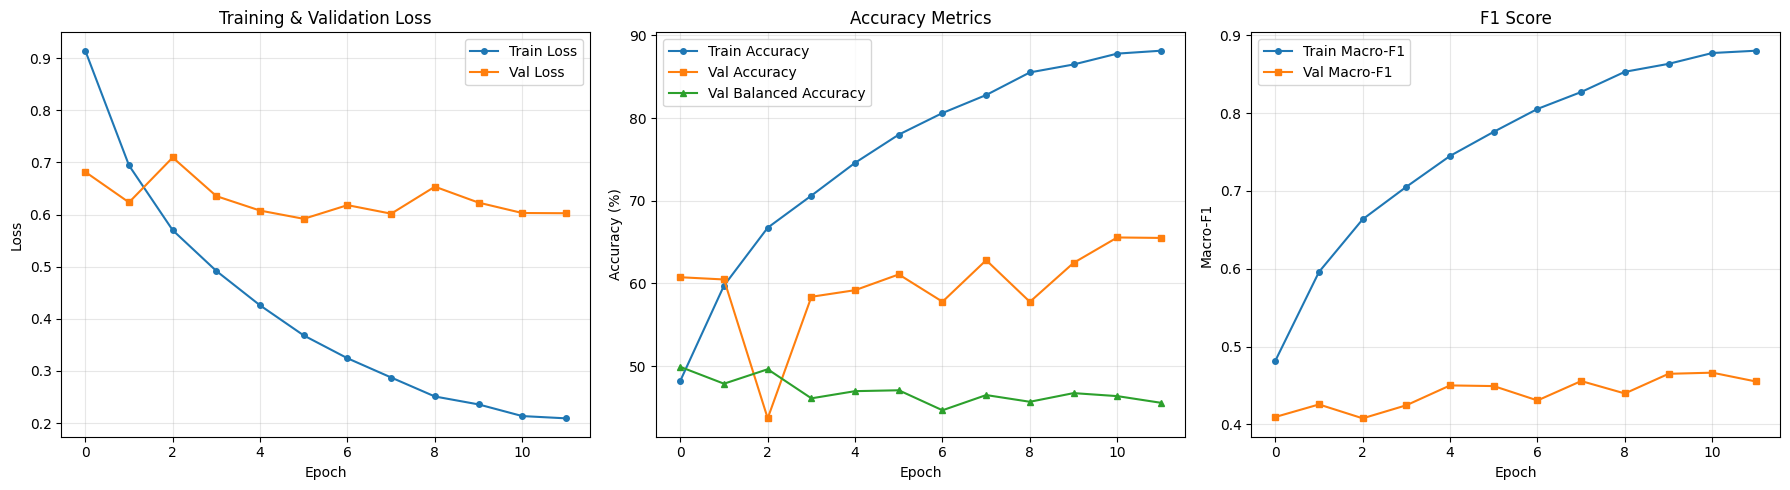

In [175]:
# plot training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x * 100 for x in history['train_acc']], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot([x * 100 for x in history['val_acc']], label='Val Accuracy', marker='s', markersize=4)
axes[1].plot([x * 100 for x in history['val_bal_acc']], label='Val Balanced Accuracy', marker='^', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train Macro-F1', marker='o', markersize=4)
axes[2].plot(history['val_f1'], label='Val Macro-F1', marker='s', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs/training_curves_distilled_deit.png', dpi=150)
plt.show()

In [ ]:


from collections import Counter
import os

print("Train labels:", Counter(train_dataset.labels))
print("Val labels:  ", Counter(val_dataset.labels))
print("Test labels: ", Counter(test_dataset.labels))

print("\nCheckpoint exists?")
print("Without distillation:", os.path.exists("SplitDATA/checkpoints/best_deit_without_distillation.pth"))
print("With distillation:   ", os.path.exists("SplitDATA/checkpoints/best_distilled_deit_model.pth"))
print("Teacher:             ", os.path.exists("SplitDATA/checkpoints/teacher_regnety160_best.pth"))

Train labels: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Val labels:   Counter({0: 5165, 2: 1050, 1: 495, 3: 178, 4: 138})
Test labels:  Counter({0: 5154, 2: 1058, 1: 493, 3: 172, 4: 149})

Checkpoint exists?
Without distillation: True
With distillation:    True
Teacher:              True


In [ ]:


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

os.makedirs("SplitDATA/logs", exist_ok=True)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs


def evaluate_and_save_test_results(
    model,
    test_loader,
    model_name,
    checkpoint_path,
    save_path,
    is_distilled=False
):
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()

    test_preds = []
    test_labels = []
    test_probs = []

    print(f"\nTesting: {model_name}")

    with torch.no_grad():

        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)
            preds = final_logits.argmax(dim=1)

            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    test_probs = np.array(test_probs)
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)

    cm = confusion_matrix(test_labels, test_preds)

    test_acc = accuracy_score(test_labels, test_preds)
    test_bal_acc = balanced_accuracy_score(test_labels, test_preds)
    macro_precision = precision_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_recall = recall_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(test_labels, test_preds, weights="quadratic")
    mcc = matthews_corrcoef(test_labels, test_preds)

    try:
        multiclass_auc = roc_auc_score(
            test_labels,
            test_probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        multiclass_auc = None

    report = classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )

    result_text = (
        f"====================================================\n"
        f"TEST RESULTS - {model_name}\n"
        f"====================================================\n\n"
        f"Checkpoint                : {checkpoint_path}\n\n"
        f"Accuracy                  : {test_acc:.4f}\n"
        f"Balanced Accuracy         : {test_bal_acc:.4f}\n"
        f"Macro Precision           : {macro_precision:.4f}\n"
        f"Macro Recall              : {macro_recall:.4f}\n"
        f"Macro F1                  : {macro_f1:.4f}\n"
        f"Weighted F1               : {weighted_f1:.4f}\n"
        f"Quadratic Weighted Kappa  : {qwk:.4f}\n"
        f"Matthews Corrcoef         : {mcc:.4f}\n"
        f"Macro ROC-AUC OvR         : {multiclass_auc if multiclass_auc is not None else 'Not available'}\n\n"
        f"Classification Report:\n"
        f"{report}\n\n"
        f"Confusion Matrix:\n"
        f"{cm}\n\n"
        f"Class-wise Sensitivity / Specificity:\n"
    )

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        result_text += (
            f"{class_name:15s} | "
            f"Sensitivity: {sensitivity:.4f} | "
            f"Specificity: {specificity:.4f}\n"
        )

    print(result_text)

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"\nSaved test results to: {save_path}")

    return {
        "accuracy": test_acc,
        "balanced_accuracy": test_bal_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "qwk": qwk,
        "mcc": mcc,
        "auc": multiclass_auc,
        "cm": cm,
        "preds": test_preds,
        "labels": test_labels,
        "probs": test_probs,
    }


baseline_test_model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=False,
    num_classes=5
).to(device)

baseline_results = evaluate_and_save_test_results(
    model=baseline_test_model,
    test_loader=test_loader,
    model_name="DeiT WITHOUT Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_deit_without_distillation.pth",
    save_path="SplitDATA/logs/test_results_deit_without_distillation.txt",
    is_distilled=False
)



distilled_test_model = timm.create_model(
    "deit_small_distilled_patch16_224",
    pretrained=False,
    num_classes=5,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(device)

distilled_results = evaluate_and_save_test_results(
    model=distilled_test_model,
    test_loader=test_loader,
    model_name="DeiT WITH Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_distilled_deit_model.pth",
    save_path="SplitDATA/logs/test_results_deit_with_distillation.txt",
    is_distilled=True
)



comparison_path = "SplitDATA/logs/test_comparison_summary_argmax.txt"
comparison_text = (
    "====================================================\n"
    "FINAL TEST COMPARISON\n"
    "====================================================\n\n"

    "1. DeiT WITHOUT Distillation\n"

    f"Argmax QWK               : {baseline_results['qwk']:.4f}\n"
    f"Tuned QWK                : {baseline_threshold_results['test_qwk']:.4f}\n"

    f"Macro F1                 : {baseline_results['macro_f1']:.4f}\n"
    f"Accuracy                 : {baseline_results['accuracy']:.4f}\n"
    f"Balanced Accuracy        : {baseline_results['balanced_accuracy']:.4f}\n\n"

    "2. DeiT WITH Distillation\n"

    f"Argmax QWK               : {distilled_results['qwk']:.4f}\n"
    f"Tuned QWK                : {distilled_threshold_results['test_qwk']:.4f}\n"

    f"Macro F1                 : {distilled_results['macro_f1']:.4f}\n"
    f"Accuracy                 : {distilled_results['accuracy']:.4f}\n"
    f"Balanced Accuracy        : {distilled_results['balanced_accuracy']:.4f}\n\n"
)




print(comparison_text)

with open(comparison_path, "w") as f:
    f.write(comparison_text)

print(f"Saved ARGMAX comparison summary to: {comparison_path}")


/tmp/ipykernel_617293/1400589135.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Testing: DeiT WITHOUT Distillation


Testing DeiT WITHOUT Distillation: 100%|██████████| 220/220 [00:11<00:00, 18.57it/s]
/tmp/ipykernel_617293/1400589135.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  to

TEST RESULTS - DeiT WITHOUT Distillation

Checkpoint                : SplitDATA/checkpoints/best_deit_without_distillation.pth

Accuracy                  : 0.7163
Balanced Accuracy         : 0.4219
Macro Precision           : 0.5065
Macro Recall              : 0.4219
Macro F1                  : 0.4514
Weighted F1               : 0.7155
Quadratic Weighted Kappa  : 0.5830
Matthews Corrcoef         : 0.3340
Macro ROC-AUC OvR         : 0.7456698288639971

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8375    0.8490    0.8432      5154
         Mild     0.0954    0.1095    0.1020       493
     Moderate     0.4733    0.4688    0.4710      1058
       Severe     0.5000    0.2326    0.3175       172
Proliferative     0.6262    0.4497    0.5234       149

     accuracy                         0.7163      7026
    macro avg     0.5065    0.4219    0.4514      7026
 weighted avg     0.7178    0.7163    0.7155      7026


Confusion Matrix:
[[43

Testing DeiT WITH Distillation: 100%|██████████| 220/220 [00:11<00:00, 18.57it/s]


TEST RESULTS - DeiT WITH Distillation

Checkpoint                : SplitDATA/checkpoints/best_distilled_deit_model.pth

Accuracy                  : 0.6625
Balanced Accuracy         : 0.4574
Macro Precision           : 0.4906
Macro Recall              : 0.4574
Macro F1                  : 0.4648
Weighted F1               : 0.6874
Quadratic Weighted Kappa  : 0.5700
Matthews Corrcoef         : 0.3104
Macro ROC-AUC OvR         : 0.7438695268745252

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8507    0.7553    0.8002      5154
         Mild     0.1107    0.2252    0.1484       493
     Moderate     0.4327    0.4953    0.4619      1058
       Severe     0.4259    0.2674    0.3286       172
Proliferative     0.6328    0.5436    0.5848       149

     accuracy                         0.6625      7026
    macro avg     0.4906    0.4574    0.4648      7026
 weighted avg     0.7208    0.6625    0.6874      7026


Confusion Matrix:
[[3893  782 

In [ ]:


from scipy.optimize import differential_evolution
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, balanced_accuracy_score
import numpy as np
import torch.nn.functional as F
import os

os.makedirs("SplitDATA/logs", exist_ok=True)

def apply_thresholds(scores, thresholds):
    thresholds = np.sort(thresholds)

    preds = np.zeros_like(scores, dtype=int)

    for i, threshold in enumerate(thresholds):
        preds[scores > threshold] = i + 1

    return preds


def get_probs_and_labels(model, loader, is_distilled=False):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(loader, desc="Collecting probabilities"):

            images = images.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


def optimize_thresholds_for_qwk(val_scores, val_labels):

    def objective(thresholds):
        thresholds = np.sort(thresholds)
        preds = apply_thresholds(val_scores, thresholds)

        qwk = cohen_kappa_score(
            val_labels,
            preds,
            weights="quadratic"
        )

        return -qwk

    bounds = [
        (val_scores.min(), val_scores.max()),
        (val_scores.min(), val_scores.max()),
        (val_scores.min(), val_scores.max()),
        (val_scores.min(), val_scores.max())
    ]

    result = differential_evolution(
        objective,
        bounds,
        seed=SEED,
        maxiter=100,
        popsize=15,
        tol=1e-6,
        polish=True
    )

    best_thresholds = np.sort(result.x)
    best_val_qwk = -result.fun

    return best_thresholds, best_val_qwk


def tune_and_apply_thresholds(model, model_name, is_distilled=False):

    print(f"\nThreshold tuning for: {model_name}")


    val_probs, val_labels = get_probs_and_labels(
        model,
        val_loader,
        is_distilled=is_distilled
    )

    val_scores = val_probs @ np.arange(5)

    best_thresholds, val_qwk_tuned = optimize_thresholds_for_qwk(
        val_scores,
        val_labels
    )

    val_preds_tuned = apply_thresholds(
        val_scores,
        best_thresholds
    )

    val_f1_tuned = f1_score(
        val_labels,
        val_preds_tuned,
        average="macro",
        zero_division=0
    )

    val_acc_tuned = accuracy_score(
        val_labels,
        val_preds_tuned
    )

    val_bal_acc_tuned = balanced_accuracy_score(
        val_labels,
        val_preds_tuned
    )



    test_probs, test_labels = get_probs_and_labels(
        model,
        test_loader,
        is_distilled=is_distilled
    )

    test_scores = test_probs @ np.arange(5)

    test_preds_tuned = apply_thresholds(
        test_scores,
        best_thresholds
    )

    test_qwk_tuned = cohen_kappa_score(
        test_labels,
        test_preds_tuned,
        weights="quadratic"
    )

    test_f1_tuned = f1_score(
        test_labels,
        test_preds_tuned,
        average="macro",
        zero_division=0
    )

    test_acc_tuned = accuracy_score(
        test_labels,
        test_preds_tuned
    )

    test_bal_acc_tuned = balanced_accuracy_score(
        test_labels,
        test_preds_tuned
    )

    result_text = (
        f"\n====================================================\n"
        f"THRESHOLD TUNING RESULTS - {model_name}\n"
        f"====================================================\n"
        f"Best thresholds             : {best_thresholds}\n\n"
        f"Tuned Validation QWK        : {val_qwk_tuned:.4f}\n"
        f"Tuned Validation Macro F1   : {val_f1_tuned:.4f}\n"
        f"Tuned Validation Accuracy   : {val_acc_tuned:.4f}\n"
        f"Tuned Validation Bal Acc    : {val_bal_acc_tuned:.4f}\n\n"
        f"Tuned Test QWK              : {test_qwk_tuned:.4f}\n"
        f"Tuned Test Macro F1         : {test_f1_tuned:.4f}\n"
        f"Tuned Test Accuracy         : {test_acc_tuned:.4f}\n"
        f"Tuned Test Bal Accuracy     : {test_bal_acc_tuned:.4f}\n"
    )

    print(result_text)

    save_path = (
        "SplitDATA/logs/threshold_tuning_"
        + model_name.replace(" ", "_").replace("-", "_").lower()
        + ".txt"
    )

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"Saved threshold tuning results to: {save_path}")

    return {
        "thresholds": best_thresholds,

        "val_qwk": val_qwk_tuned,
        "val_macro_f1": val_f1_tuned,
        "val_accuracy": val_acc_tuned,
        "val_balanced_accuracy": val_bal_acc_tuned,

        "test_qwk": test_qwk_tuned,
        "test_macro_f1": test_f1_tuned,
        "test_accuracy": test_acc_tuned,
        "test_balanced_accuracy": test_bal_acc_tuned,

        "test_preds": test_preds_tuned,
        "test_labels": test_labels,
        "test_probs": test_probs
    }



baseline_threshold_results = tune_and_apply_thresholds(
    baseline_test_model,
    "DeiT WITHOUT Distillation",
    is_distilled=False
)


distilled_threshold_results = tune_and_apply_thresholds(
    distilled_test_model,
    "DeiT WITH Distillation",
    is_distilled=True
)


Threshold tuning for: DeiT WITHOUT Distillation



THRESHOLD TUNING RESULTS - DeiT WITHOUT Distillation
Best thresholds             : [0.90274303 1.46764247 1.86408447 2.05305707]

Tuned Validation QWK        : 0.6464
Tuned Validation Macro F1   : 0.3615
Tuned Validation Accuracy   : 0.6847
Tuned Validation Bal Acc    : 0.4052

Tuned Test QWK              : 0.6598
Tuned Test Macro F1         : 0.3657
Tuned Test Accuracy         : 0.6958
Tuned Test Bal Accuracy     : 0.4009

Saved threshold tuning results to: SplitDATA/logs/threshold_tuning_deit_without_distillation.txt

Threshold tuning for: DeiT WITH Distillation



THRESHOLD TUNING RESULTS - DeiT WITH Distillation
Best thresholds             : [0.95081463 1.6173777  1.88088218 2.8933592 ]

Tuned Validation QWK        : 0.6411
Tuned Validation Macro F1   : 0.3912
Tuned Validation Accuracy   : 0.6867
Tuned Validation Bal Acc    : 0.4329

Tuned Test QWK              : 0.6616
Tuned Test Macro F1         : 0.4115
Tuned Test Accuracy         : 0.6957
Tuned Test Bal Accuracy     : 0.4537

Saved threshold tuning results to: SplitDATA/logs/threshold_tuning_deit_with_distillation.txt


In [ ]:


import pandas as pd
from IPython.display import display

threshold_comparison_df = pd.DataFrame({
    "Metric": [
        "Tuned Test QWK",
        "Tuned Test Macro F1",
        "Tuned Test Accuracy",
        "Tuned Test Balanced Accuracy"
    ],
    "DeiT WITHOUT Distillation": [
        baseline_threshold_results["test_qwk"],
        baseline_threshold_results["test_macro_f1"],
        baseline_threshold_results["test_accuracy"],
        baseline_threshold_results["test_balanced_accuracy"]
    ],
    "DeiT WITH Distillation": [
        distilled_threshold_results["test_qwk"],
        distilled_threshold_results["test_macro_f1"],
        distilled_threshold_results["test_accuracy"],
        distilled_threshold_results["test_balanced_accuracy"]
    ]
})

threshold_comparison_df.iloc[:, 1:] = threshold_comparison_df.iloc[:, 1:].round(4)

display(
    threshold_comparison_df.style.set_caption(
        "Threshold-Tuned Test Results"
    )
)

threshold_comparison_df.to_csv(
    "SplitDATA/logs/threshold_tuned_comparison_table.csv",
    index=False
)

,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Tuned Test QWK,0.659800,0.661600
1,Tuned Test Macro F1,0.365700,0.411500
2,Tuned Test Accuracy,0.695800,0.695700
3,Tuned Test Balanced Accuracy,0.400900,0.453700


In [181]:
from collections import Counter

print("WITHOUT DISTILLATION")
print("True labels:")
print(Counter(baseline_results["labels"]))

print("\nPredicted labels:")
print(Counter(baseline_results["preds"]))


print("\n====================================================")

print("\nWITH DISTILLATION")
print("True labels:")
print(Counter(distilled_results["labels"]))

print("\nPredicted labels:")
print(Counter(distilled_results["preds"]))

WITHOUT DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 5225, np.int64(2): 1048, np.int64(1): 566, np.int64(4): 107, np.int64(3): 80})


WITH DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 4576, np.int64(2): 1211, np.int64(1): 1003, np.int64(4): 128, np.int64(3): 108})


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("SplitDATA/logs/confusion_matrices", exist_ok=True)

def save_confusion_matrix(cm, class_names, title, save_path):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.close()

    print(f"Saved confusion matrix: {save_path}")


save_confusion_matrix(
    baseline_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITHOUT Distillation",
    "SplitDATA/logs/confusion_matrices/cm_without_distillation.png"
)



save_confusion_matrix(
    distilled_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITH Distillation",
    "SplitDATA/logs/confusion_matrices/cm_with_distillation.png"
)

Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_without_distillation.png
Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_with_distillation.png


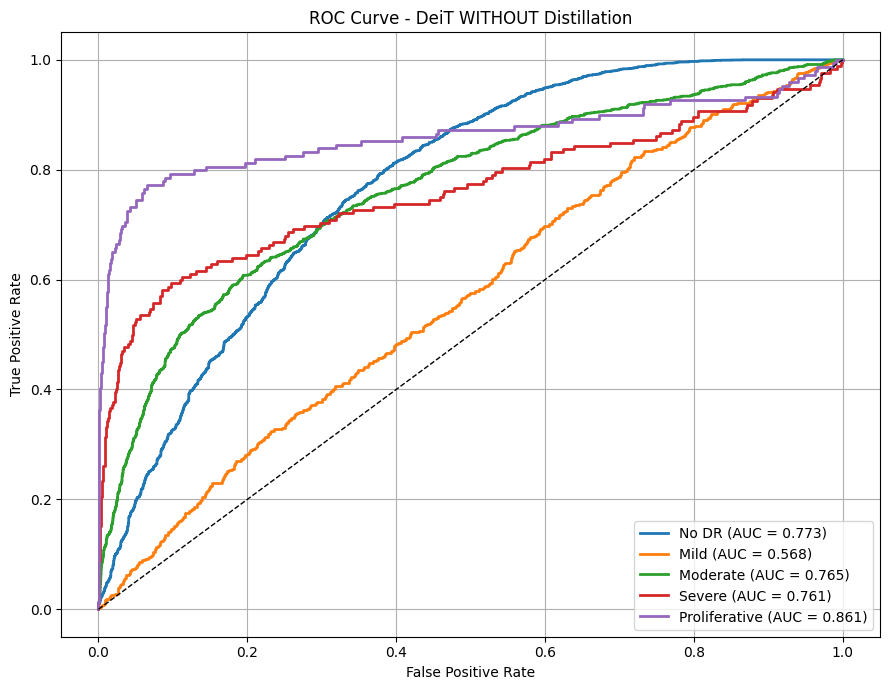

Saved ROC curve: SplitDATA/logs/roc_curves/roc_without_distillation.png


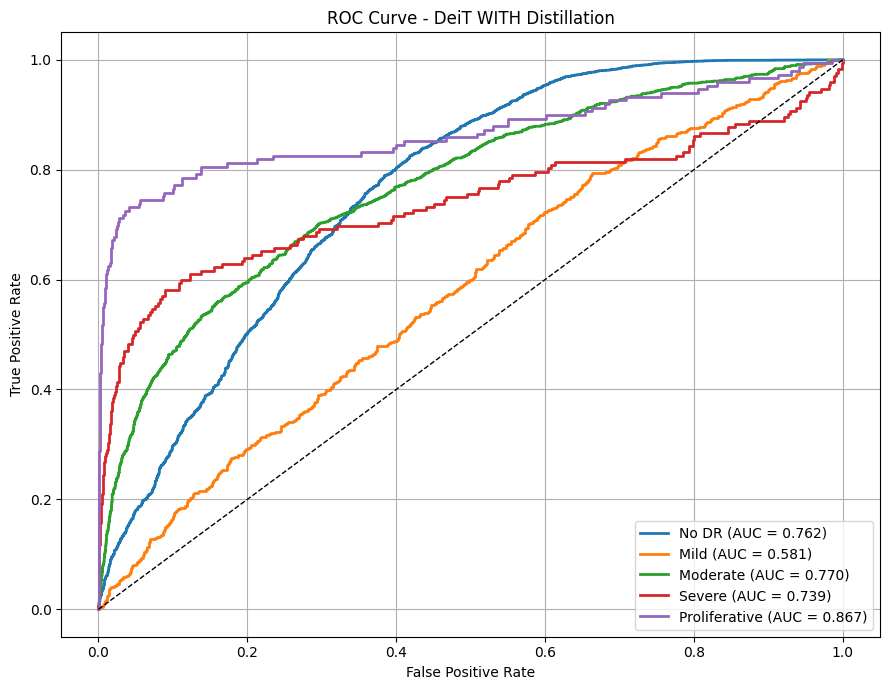

Saved ROC curve: SplitDATA/logs/roc_curves/roc_with_distillation.png


In [ ]:


import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

os.makedirs("SplitDATA/logs/roc_curves", exist_ok=True)

def plot_multiclass_roc(
    test_labels,
    test_probs,
    class_names,
    title,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0,1,2,3,4]
    )

    n_classes = y_true_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(9, 7))

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
        )

    # random baseline
    plt.plot([0,1], [0,1], 'k--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.show()

    print(f"Saved ROC curve: {save_path}")



plot_multiclass_roc(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_without_distillation.png"
)



plot_multiclass_roc(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITH Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_with_distillation.png"
)

In [ ]:


from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize
from IPython.display import display
import pandas as pd
import numpy as np
import os

os.makedirs("SplitDATA/logs", exist_ok=True)



def compute_map(
    test_labels,
    test_probs,
    class_names,
    model_name,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0, 1, 2, 3, 4]
    )

    n_classes = y_true_bin.shape[1]

    ap_per_class = []

    result_text = (
        f"====================================================\n"
        f"mAP RESULTS - {model_name}\n"
        f"====================================================\n\n"
    )

    print(f"\n{model_name}")

    for i in range(n_classes):

        ap = average_precision_score(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        ap_per_class.append(ap)

        result_text += f"{class_names[i]} AP: {ap:.4f}\n"

        print(f"{class_names[i]} AP: {ap:.4f}")

    mAP = np.mean(ap_per_class)

    result_text += f"\nmAP: {mAP:.4f}\n"

    print(f"\nmAP: {mAP:.4f}")

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"Saved mAP results to: {save_path}")

    return {
        "ap_per_class": ap_per_class,
        "mAP": mAP
    }



baseline_map_results = compute_map(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    model_name="DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/map_without_distillation.txt"
)


distilled_map_results = compute_map(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    model_name="DeiT WITH Distillation",
    save_path="SplitDATA/logs/map_with_distillation.txt"
)



map_summary_path = "SplitDATA/logs/map_comparison_summary.txt"

summary_text = (
    "====================================================\n"
    "FINAL mAP COMPARISON\n"
    "====================================================\n\n"
    "DeiT WITHOUT Distillation\n"
    f"mAP: {baseline_map_results['mAP']:.4f}\n\n"
    "DeiT WITH Distillation\n"
    f"mAP: {distilled_map_results['mAP']:.4f}\n"
)

print(summary_text)

with open(map_summary_path, "w") as f:
    f.write(summary_text)

print(f"Saved mAP comparison summary to: {map_summary_path}")


comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "QWK",
        "MCC",
        "ROC-AUC OvR",
        "mAP"
    ],

    "DeiT WITHOUT Distillation": [
        baseline_results["accuracy"],
        baseline_results["balanced_accuracy"],
        baseline_results["macro_precision"],
        baseline_results["macro_recall"],
        baseline_results["macro_f1"],
        baseline_results["weighted_f1"],
        baseline_results["qwk"],
        baseline_results["mcc"],
        baseline_results["auc"] if baseline_results["auc"] is not None else np.nan,
        baseline_map_results["mAP"]
    ],

    "DeiT WITH Distillation": [
        distilled_results["accuracy"],
        distilled_results["balanced_accuracy"],
        distilled_results["macro_precision"],
        distilled_results["macro_recall"],
        distilled_results["macro_f1"],
        distilled_results["weighted_f1"],
        distilled_results["qwk"],
        distilled_results["mcc"],
        distilled_results["auc"] if distilled_results["auc"] is not None else np.nan,
        distilled_map_results["mAP"]
    ]
    
    
})


comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

print("\nFINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")

display(
    comparison_df.style
    .set_caption("Original Argmax Results: DeiT Without vs With Distillation")
    .set_properties(**{
        "text-align": "center"
    })
)



table_csv_path = "SplitDATA/logs/final_comparison_table_argmax.csv"
table_txt_path = "SplitDATA/logs/final_comparison_table_argmax.txt"

comparison_df.to_csv(table_csv_path, index=False)

with open(table_txt_path, "w") as f:
    f.write("FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")
    f.write("====================================================\n\n")
    f.write(comparison_df.to_string(index=False))

print(f"Saved argmax comparison CSV to: {table_csv_path}")
print(f"Saved argmax comparison TXT to: {table_txt_path}")


DeiT WITHOUT Distillation
No DR AP: 0.8800
Mild AP: 0.0885
Moderate AP: 0.4304
Severe AP: 0.2746
Proliferative AP: 0.5266

mAP: 0.4400
Saved mAP results to: SplitDATA/logs/map_without_distillation.txt

DeiT WITH Distillation
No DR AP: 0.8745
Mild AP: 0.0916
Moderate AP: 0.4356
Severe AP: 0.2904
Proliferative AP: 0.5274

mAP: 0.4439
Saved mAP results to: SplitDATA/logs/map_with_distillation.txt
FINAL mAP COMPARISON

DeiT WITHOUT Distillation
mAP: 0.4400

DeiT WITH Distillation
mAP: 0.4439

Saved mAP comparison summary to: SplitDATA/logs/map_comparison_summary.txt

FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS



,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Accuracy,0.716300,0.662500
1,Balanced Accuracy,0.421900,0.457400
2,Macro Precision,0.506500,0.490600
3,Macro Recall,0.421900,0.457400
4,Macro F1,0.451400,0.464800
5,Weighted F1,0.715500,0.687400
6,QWK,0.583000,0.570000
7,MCC,0.334000,0.310400
8,ROC-AUC OvR,0.745700,0.743900
9,mAP,0.440000,0.443900


Saved argmax comparison CSV to: SplitDATA/logs/final_comparison_table_argmax.csv
Saved argmax comparison TXT to: SplitDATA/logs/final_comparison_table_argmax.txt
